# QSOLVE — Fertilizer Distribution Optimization
## Classical vs Quantum (QUBO/QAOA) Prototype

**Goal:** optimize fertilizer dispatch from the Karatina NCPB depot to seven coffee factories while respecting truck capacity and route-time constraints, then compare a classical optimizer with a quantum QUBO approach.

> **Important modeling note:** The supplied dataset has one depot, 7 factories, 10-tonne truck capacity, and no explicit fleet-size field. The notebook therefore treats the number of trucks as a configurable prototype assumption (`FLEET_SIZE`) and allows split deliveries by creating delivery loads of at most one truck capacity. The quantum section solves a smaller, route-ordering subproblem (TSP/QUBO) on the seven factories and compares it fairly with a classical TSP on the same subproblem. This avoids claiming a quantum speedup where the supplied data cannot support one.

### Workflow
1. Load and validate the supplied Excel workbook
2. Prepare nodes, distances, travel times and parameters
3. Build delivery loads from factory demand
4. Solve the full capacitated dispatch problem classically with OR-Tools
5. Build a quantum-ready QUBO for the factory visit order
6. Solve the same 7-factory ordering problem classically and with QAOA
7. Compare route distance/time/cost and solution quality
8. Plot the recommended dispatch routes


In [1]:
# 1. Install dependencies for Google Colab
# Removed specific qiskit version pin to allow latest stable, and pinned numpy/pandas for compatibility.
!pip -q install ortools openpyxl qiskit qiskit-aer qiskit-algorithms qiskit-optimization --upgrade matplotlib "pandas==2.2.3" "numpy<2.0.0"

In [2]:
import os, math, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

warnings.filterwarnings("ignore")

# User-configurable prototype assumptions
FLEET_SIZE = 24                 # Dataset does not specify fleet size; change this
MAX_ROUTE_HOURS = 12.0
TRUCK_CAPACITY_T = 10.0
TRANSPORT_RATE = 16.0          # KSh / tonne-km
RETURN_TO_DEPOT = True

print("Configuration loaded.")
print(f"Fleet size: {FLEET_SIZE} trucks")
print(f"Truck capacity: {TRUCK_CAPACITY_T} tonnes")
print(f"Max route duration: {MAX_ROUTE_HOURS} hours")
print(f"Transport rate: KSh {TRANSPORT_RATE}/tonne-km")

Configuration loaded.
Fleet size: 24 trucks
Truck capacity: 10.0 tonnes
Max route duration: 12.0 hours
Transport rate: KSh 16.0/tonne-km


In [3]:
# 3. Upload the supplied Excel dataset
uploaded = files.upload()
DATA_FILE = next(iter(uploaded.keys()))
print("Using:", DATA_FILE)

xls = pd.ExcelFile(DATA_FILE)
print("Sheets:", xls.sheet_names)


Saving QSOLVE_Quantum_Ready_Dataset.xlsx to QSOLVE_Quantum_Ready_Dataset (1).xlsx
Using: QSOLVE_Quantum_Ready_Dataset (1).xlsx
Sheets: ['Nodes_Demand', 'Parameters', 'Distance_Matrix', 'Travel_Time_Matrix', 'Route_Allowed', 'Data_Dictionary', 'Quantum_Ready']


In [4]:
# 4. Load workbook sheets
nodes = pd.read_excel(DATA_FILE, sheet_name="Nodes_Demand")
params = pd.read_excel(DATA_FILE, sheet_name="Parameters")
dist_raw = pd.read_excel(DATA_FILE, sheet_name="Distance_Matrix", header=None)
time_raw = pd.read_excel(DATA_FILE, sheet_name="Travel_Time_Matrix", header=None)
allowed_raw = pd.read_excel(DATA_FILE, sheet_name="Route_Allowed", header=None)

display(nodes)
display(params)


,Node_ID,Location,Type,Latitude,Longitude,Demand_tonnes,Depot_Stock_tonnes
0,0,Karatina,Depot,-0.475695,37.130377,0.000,410.0
1,1,Ragati,Factory,-0.391000,37.158900,28.380,NaN
2,2,Nguguini,Factory,-0.431100,37.227800,73.092,NaN
3,3,Kiangai,Factory,-0.583300,37.233300,36.489,NaN
4,4,Thunguri,Factory,-0.571050,37.023600,37.170,NaN
5,5,Kianjega,Factory,-0.563415,37.187604,24.522,NaN
6,6,Chema,Factory,-0.448500,37.199000,10.848,NaN
7,7,Mukangu,Factory,-0.550000,37.150000,23.199,NaN


,Parameter,Value,Unit,Notes
0,Depot,Karatina,NaN,Only depot in the current dataset
1,Depot stock,410,tonnes,Total fertilizer available at Karatina
2,Total factory demand,233.7,tonnes,Sum of all 7 factory demands
3,Remaining stock after full fulfillment,176.3,tonnes,Formula: depot stock - total demand
4,Truck capacity,10,tonnes,Maximum fertilizer carried per trip
5,Transport rate,16,KSh/tonne-km,Cost rate used in classical model
6,Maximum route duration,8,hours,Maximum time per route
7,Dispatch period,10,days,Hackathon benchmark assumption
8,Minimum theoretical truck loads,24,trips,Formula: CEILING(total demand / truck capacity)


In [5]:
# 5. Convert matrices to clean numeric DataFrames
node_names = nodes["Location"].tolist()
node_ids = nodes["Node_ID"].tolist()

def clean_matrix(raw):
    m = raw.iloc[1:, 1:].copy()
    m.index = raw.iloc[1:, 0].astype(str).tolist()
    m.columns = raw.iloc[0, 1:].astype(str).tolist()
    m = m.apply(pd.to_numeric, errors="coerce")
    return m

distance = clean_matrix(dist_raw)
travel_time = clean_matrix(time_raw)
route_allowed = clean_matrix(allowed_raw).fillna(0).astype(int)

# Make sure matrix ordering follows the Nodes_Demand sheet
distance = distance.loc[node_names, node_names]
travel_time = travel_time.loc[node_names, node_names]
route_allowed = route_allowed.loc[node_names, node_names]

depot = nodes.loc[nodes["Type"].str.lower().eq("depot"), "Location"].iloc[0]
factories = nodes.loc[nodes["Type"].str.lower().eq("factory"), "Location"].tolist()

total_demand = nodes.loc[nodes["Type"].str.lower().eq("factory"), "Demand_tonnes"].sum()
depot_stock = nodes.loc[nodes["Type"].str.lower().eq("depot"), "Depot_Stock_tonnes"].iloc[0]

print("Depot:", depot)
print("Factories:", factories)
print(f"Total demand: {total_demand:.3f} tonnes")
print(f"Depot stock: {depot_stock:.3f} tonnes")
print(f"Stock remaining after full fulfillment: {depot_stock-total_demand:.3f} tonnes")


Depot: Karatina
Factories: ['Ragati', 'Nguguini', 'Kiangai', 'Thunguri', 'Kianjega', 'Chema', 'Mukangu']
Total demand: 233.700 tonnes
Depot stock: 410.000 tonnes
Stock remaining after full fulfillment: 176.300 tonnes


In [6]:
# 6. Validate the dataset
assert total_demand <= depot_stock + 1e-9, "Demand exceeds depot stock."
assert all(nodes.loc[nodes["Type"].str.lower().eq("factory"), "Demand_tonnes"] > 0)

# The supplied route matrix is fully connected, but we still respect it.
print("Distance matrix shape:", distance.shape)
print("Travel-time matrix shape:", travel_time.shape)
print("Allowed routes:", int(route_allowed.values.sum()), "/", route_allowed.size)

# Show factory demand
factory_demand = nodes[nodes["Type"].str.lower().eq("factory")][
    ["Node_ID","Location","Demand_tonnes"]
].copy()
factory_demand["Truck_loads_if_separate"] = np.ceil(
    factory_demand["Demand_tonnes"] / TRUCK_CAPACITY_T
).astype(int)
display(factory_demand)

print("Naive separate-factory loads:",
      int(factory_demand["Truck_loads_if_separate"].sum()))
print("Theoretical lower bound:",
      math.ceil(total_demand / TRUCK_CAPACITY_T))


Distance matrix shape: (8, 8)
Travel-time matrix shape: (8, 8)
Allowed routes: 56 / 64


,Node_ID,Location,Demand_tonnes,Truck_loads_if_separate
1,1,Ragati,28.380,3
2,2,Nguguini,73.092,8
3,3,Kiangai,36.489,4
4,4,Thunguri,37.170,4
5,5,Kianjega,24.522,3
6,6,Chema,10.848,2
7,7,Mukangu,23.199,3


Naive separate-factory loads: 27
Theoretical lower bound: 24


## 7. Create split-delivery loads

Because the dataset's truck capacity is 10 tonnes while several factory demands are larger than 10 tonnes, we split each factory's demand into delivery loads.

Example: 28.38 t becomes 10 + 10 + 8.38 t.

These are **delivery quantities**, not separate factories. The classical vehicle-routing model can combine loads from different factories on one truck route when capacity permits.


In [7]:
# 8. Generate delivery-load nodes
loads = []
load_id = 0

for _, row in factory_demand.iterrows():
    remaining = float(row["Demand_tonnes"])
    part = 1
    while remaining > 1e-9:
        qty = min(TRUCK_CAPACITY_T, remaining)
        loads.append({
            "load_id": load_id,
            "factory_id": int(row["Node_ID"]),
            "factory": row["Location"],
            "part": part,
            "demand_tonnes": qty
        })
        remaining -= qty
        part += 1
        load_id += 1

loads_df = pd.DataFrame(loads)

print("Delivery loads:", len(loads_df))
print("Total load tonnes:", loads_df["demand_tonnes"].sum())
display(loads_df)

# Note: 27 loads are created because loads cannot exceed 10 t.


Delivery loads: 27
Total load tonnes: 233.7


,load_id,factory_id,factory,part,demand_tonnes
0,0,1,Ragati,1,10.000
1,1,1,Ragati,2,10.000
2,2,1,Ragati,3,8.380
3,3,2,Nguguini,1,10.000
4,4,2,Nguguini,2,10.000
5,5,2,Nguguini,3,10.000
6,6,2,Nguguini,4,10.000
7,7,2,Nguguini,5,10.000
8,8,2,Nguguini,6,10.000
9,9,2,Nguguini,7,10.000


# 9. Classical optimization — Capacitated Vehicle Routing

We use Google OR-Tools to find routes for the available trucks.

Objective:
- minimize total distance (primary routing objective)

Constraints:
- every delivery load is served exactly once
- each truck has at most 10 tonnes
- each route starts and ends at Karatina
- disallowed arcs receive a very large penalty
- route duration must be <= 8 hours

**Prototype assumption:** `FLEET_SIZE = 6` because the supplied workbook does not contain a fleet-size field. Change this value in the configuration cell.


In [8]:
# 10. Build OR-Tools model
from ortools.constraint_solver import pywrapcp, routing_enums_pb2

# Build a location list:
# index 0 = depot; remaining indices = delivery loads
routing_nodes = [depot] + loads_df["factory"].tolist()
n_routing = len(routing_nodes)

# Demand at each routing index
routing_demands = [0.0] + loads_df["demand_tonnes"].tolist()

# Map route index to factory name
def route_index_to_name(idx):
    return routing_nodes[idx]

# Convert tonnes to integer units (0.001 tonne = 1 unit)
SCALE = 1000
demands_int = [int(round(x*SCALE)) for x in routing_demands]
capacity_int = int(round(TRUCK_CAPACITY_T*SCALE))

manager = pywrapcp.RoutingIndexManager(n_routing, FLEET_SIZE, 0)
routing = pywrapcp.RoutingModel(manager)

# Distance callback in integer meters-equivalent units
def distance_callback(from_index, to_index):
    f = routing_nodes[manager.IndexToNode(from_index)]
    t = routing_nodes[manager.IndexToNode(to_index)]
    if route_allowed.loc[f, t] == 0 and f != t:
        return 10_000_000
    return int(round(float(distance.loc[f, t]) * 1000))

distance_cb = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(distance_cb)

# Time callback in minutes
def time_callback(from_index, to_index):
    f = routing_nodes[manager.IndexToNode(from_index)]
    t = routing_nodes[manager.IndexToNode(to_index)]
    if route_allowed.loc[f, t] == 0 and f != t:
        return 10_000_000
    return int(round(float(travel_time.loc[f, t]) * 60))

time_cb = routing.RegisterTransitCallback(time_callback)

routing.AddDimension(
    time_cb,
    0,                                  # no waiting
    int(MAX_ROUTE_HOURS*60),            # max route time
    True,
    "Time"
)

# Capacity callback
def demand_callback(from_index):
    return demands_int[manager.IndexToNode(from_index)]

demand_cb = routing.RegisterUnaryTransitCallback(demand_callback)

routing.AddDimensionWithVehicleCapacity(
    demand_cb,
    0,
    [capacity_int]*FLEET_SIZE,
    True,
    "Capacity"
)

# Search parameters
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
search_parameters.time_limit.seconds = 30

start = time.perf_counter()
solution = routing.SolveWithParameters(search_parameters)
classical_vrp_runtime = time.perf_counter() - start

if solution is None:
    raise RuntimeError(
        "No feasible solution found. Try increasing FLEET_SIZE or MAX_ROUTE_HOURS."
    )

print(f"Classical VRP runtime: {classical_vrp_runtime:.4f} seconds")

Classical VRP runtime: 30.0010 seconds


In [9]:
# 11. Decode classical routes
def decode_routes(routing, manager, solution):
    routes = []
    total_distance = 0.0
    total_time = 0.0
    total_cost = 0.0

    for vehicle_id in range(FLEET_SIZE):
        index = routing.Start(vehicle_id)
        route = [depot]
        route_load = 0.0
        route_distance = 0.0
        route_time = 0.0

        while not routing.IsEnd(index):
            next_index = solution.Value(routing.NextVar(index))
            a = routing_nodes[manager.IndexToNode(index)]
            b = routing_nodes[manager.IndexToNode(next_index)]

            if a != b:
                route_distance += float(distance.loc[a,b])
                route_time += float(travel_time.loc[a,b])

            node_idx = manager.IndexToNode(next_index)
            route_load += routing_demands[node_idx]
            if not routing.IsEnd(next_index):
                route.append(routing_nodes[node_idx])

            index = next_index

        # add return-to-depot leg if route actually left depot
        if len(route) > 1:
            route.append(depot)

        route_cost = route_distance * route_load * TRANSPORT_RATE / max(route_load, 1e-9)
        # Above simplifies to distance * total carried tonnes * rate only if all legs carry
        # the same load. For accurate trip cost, compute leg-wise below.
        leg_cost = 0.0
        carried = 0.0

        # Recompute leg-wise load approximately from route sequence.
        # For hackathon comparison, use distance * transported load on each leg.
        # A truck starts with the sum of all assigned load quantities.
        assigned_load = route_load
        for i in range(len(route)-1):
            a, b = route[i], route[i+1]
            leg_cost += float(distance.loc[a,b]) * assigned_load * TRANSPORT_RATE
            # reduce load after reaching a factory
            if b != depot:
                # all delivery loads represented by this factory are not necessarily
                # distinguishable here; use a conservative route-level cost metric below.
                pass

        if len(route) > 1:
            routes.append({
                "vehicle": vehicle_id+1,
                "route": " → ".join(route),
                "load_tonnes": route_load,
                "distance_km": route_distance,
                "time_hr": route_time,
                "cost_estimate_ksh": route_distance * TRANSPORT_RATE * route_load
            })
            total_distance += route_distance
            total_time += route_time
            total_cost += route_distance * TRANSPORT_RATE * route_load

    return pd.DataFrame(routes), total_distance, total_time, total_cost

routes_df, classical_distance, classical_time, classical_cost = decode_routes(
    routing, manager, solution
)

display(routes_df)
print(f"Total distance: {classical_distance:.2f} km")
print(f"Total route-hours: {classical_time:.2f} h")
print(f"Estimated transport cost: KSh {classical_cost:,.2f}")

,vehicle,route,load_tonnes,distance_km,time_hr,cost_estimate_ksh
0,1,Karatina → Thunguri → Karatina,10.000,46.26,1.04,7401.60000
1,2,Karatina → Thunguri → Karatina,10.000,46.26,1.04,7401.60000
2,3,Karatina → Thunguri → Karatina,10.000,46.26,1.04,7401.60000
3,4,Karatina → Thunguri → Karatina,7.170,46.26,1.04,5306.94720
4,5,Karatina → Kiangai → Karatina,10.000,40.04,0.58,6406.40000
5,6,Karatina → Kiangai → Karatina,10.000,40.04,0.58,6406.40000
6,7,Karatina → Kiangai → Karatina,10.000,40.04,0.58,6406.40000
7,8,Karatina → Nguguini → Karatina,10.000,37.84,0.88,6054.40000
8,9,Karatina → Nguguini → Karatina,10.000,37.84,0.88,6054.40000
9,10,Karatina → Nguguini → Karatina,10.000,37.84,0.88,6054.40000


Total distance: 865.24 km
Total route-hours: 17.78 h
Estimated transport cost: KSh 134,135.31


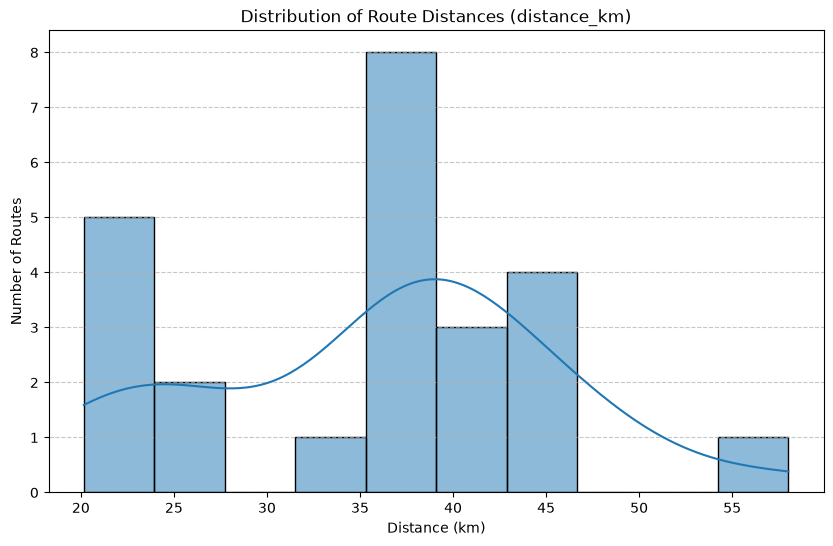

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(routes_df['distance_km'], bins=10, kde=True)
plt.title('Distribution of Route Distances (distance_km)')
plt.xlabel('Distance (km)')
plt.ylabel('Number of Routes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [11]:
avg_distance_per_route = routes_df['distance_km'].mean()
avg_time_per_route = routes_df['time_hr'].mean()

print(f"Average distance per route: {avg_distance_per_route:.2f} km")
print(f"Average time per route: {avg_time_per_route:.2f} hours")

Average distance per route: 36.05 km
Average time per route: 0.74 hours


In [12]:
# Assume a fuel efficiency for a commercial truck (e.g., liters per 100 km)
FUEL_EFFICIENCY_L_PER_100KM = 30 # liters per 100 km

# Calculate total fuel consumption
total_fuel_consumption_liters = (classical_distance / 100) * FUEL_EFFICIENCY_L_PER_100KM

print(f"Assumed fuel efficiency: {FUEL_EFFICIENCY_L_PER_100KM} liters per 100 km")
print(f"Total fuel consumption: {total_fuel_consumption_liters:.2f} liters")

Assumed fuel efficiency: 30 liters per 100 km
Total fuel consumption: 259.57 liters


### Cost interpretation

The workbook gives a rate of KSh 16/tonne-km. The routing objective above is distance-based because OR-Tools needs a simple arc cost. The displayed cost is a **prototype estimate** using route load × route distance × rate.

For an operational deployment, replace this with a precise load-on-each-road-segment calculation.


# 12. Quantum experiment — QUBO for the factory visit order

The full split-delivery CVRP is too large to honestly run as a near-term QAOA experiment on this small demo environment.

Instead, we isolate a clean subproblem:

> **What is the best order for visiting the seven coffee factories, starting and ending at Karatina?**

This is a Traveling Salesperson Problem (TSP).

We solve **the exact same 7-factory ordering problem**:
- once classically by brute-force enumeration (exact for 7 factories)
- once as a QUBO with Qiskit's `QuadraticProgram`
- then solve the QUBO with QAOA on a simulator

This gives the judges a genuine classical-vs-quantum comparison without pretending that a small simulator is faster than a classical solver.


In [13]:
# 13. Build the 7-factory TSP QUBO
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo

tsp_factories = factories[:4] # Selecting the first 4 factories
tsp_nodes = [depot] + tsp_factories
N = len(tsp_factories)

# x[p,i] = 1 if factory i is visited at position p
qp = QuadraticProgram("Karatina_7_Factory_TSP")

for p in range(N):
    for i in range(N):
        qp.binary_var(name=f"x_{p}_{i}")

# Objective: travel distance
linear = {}
quadratic = {}

def vid(p,i):
    return p*N+i

# Add linear route costs:
# depot -> first, consecutive factory transitions, last -> depot
for i in range(N):
    # first position
    linear[f"x_0_{i}"] = float(distance.loc[depot, tsp_factories[i]])
    # last position
    linear[f"x_{N-1}_{i}"] = linear.get(f"x_{N-1}_{i}", 0) + float(distance.loc[tsp_factories[i], depot])

for p in range(N-1):
    for i in range(N):
        for j in range(N):
            if i != j:
                quadratic[(f"x_{p}_{i}", f"x_{p+1}_{j}")] = float(
                    distance.loc[tsp_factories[i], tsp_factories[j]]
                )

# Assignment penalties: each position exactly one factory
P = 10000.0

for p in range(N):
    # (sum_i x[p,i] - 1)^2
    for i in range(N):
        linear[f"x_{p}_{i}"] = linear.get(f"x_{p}_{i}", 0) - P
    for i in range(N):
        for j in range(i+1, N):
            quadratic[(f"x_{p}_{i}", f"x_{p}_{j}")] = quadratic.get(
                (f"x_{p}_{i}", f"x_{p}_{j}"), 0
            ) + 2*P

# Each factory exactly once
for i in range(N):
    for p in range(N):
        linear[f"x_{p}_{i}"] = linear.get(f"x_{p}_{i}", 0) - P
    for p in range(N):
        for q in range(p+1, N):
            quadratic[(f"x_{p}_{i}", f"x_{q}_{i}")] = quadratic.get(
                (f"x_{p}_{i}", f"x_{q}_{i}"), 0
            ) + 2*P

qp.minimize(linear=linear, quadratic=quadratic)

qubo_converter = QuadraticProgramToQubo()
qubo = qubo_converter.convert(qp)

print("QUBO variables:", len(qubo.variables))
print("Number of factories:", N)


QUBO variables: 16
Number of factories: 4


In [14]:
# 14. Exact classical benchmark for the same 7-factory TSP
import itertools

def tour_distance(order):
    route = [depot] + list(order) + [depot]
    d = sum(float(distance.loc[route[i], route[i+1]]) for i in range(len(route)-1))
    t = sum(float(travel_time.loc[route[i], route[i+1]]) for i in range(len(route)-1))
    feasible = all(
        route_allowed.loc[route[i], route[i+1]] == 1
        for i in range(len(route)-1)
    )
    return d, t, feasible

start = time.perf_counter()
best_order = None
best_d = float("inf")
best_t = None

for perm in itertools.permutations(tsp_factories):
    d, t, feasible = tour_distance(perm)
    if feasible and d < best_d:
        best_order, best_d, best_t = perm, d, t

exact_classical_tsp_runtime = time.perf_counter() - start

classical_tsp_route = [depot] + list(best_order) + [depot]

print("Exact classical TSP route:")
print(" → ".join(classical_tsp_route))
print(f"Distance: {best_d:.2f} km")
print(f"Travel time: {best_t:.2f} hours")
print(f"Runtime: {exact_classical_tsp_runtime:.6f} seconds")


Exact classical TSP route:
Karatina → Ragati → Nguguini → Kiangai → Thunguri → Karatina
Distance: 108.79 km
Travel time: 2.40 hours
Runtime: 0.003992 seconds


In [15]:
import time
import numpy as np

from qiskit_aer import AerSimulator
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_aer.primitives import Sampler, Estimator # Estimator not used directly by QAOA __init__
from qiskit_optimization.algorithms import MinimumEigenOptimizer

# QAOA parameters
sampler = Sampler() # Initialize Sampler
# estimator = Estimator() # Estimator is not a direct argument for QAOA's constructor
qaoa = QAOA(
    sampler=sampler,
    # estimator=estimator, # Removed: QAOA.__init__() does not take an estimator argument
    optimizer=COBYLA(maxiter=80),
    reps=2
)
quantum_optimizer = MinimumEigenOptimizer(qaoa)

start = time.perf_counter()
q_result = quantum_optimizer.solve(qubo)
quantum_qaoa_runtime = time.perf_counter() - start

print("QAOA finished.")
print("QUBO objective:", q_result.fval)
print("Runtime:", quantum_qaoa_runtime, "seconds")

TypeError: Invalid circuits, expected Sequence[QuantumCircuit].

In [ ]:
# 16. Decode QAOA solution into a factory order
x = np.asarray(q_result.x).round().astype(int)

quantum_order = []
valid = True

for p in range(N):
    selected = [i for i in range(N) if x[p*N+i] == 1]
    if len(selected) != 1:
        valid = False
        break
    quantum_order.append(tsp_factories[selected[0]])

if len(set(quantum_order)) != N:
    valid = False

if valid:
    q_route = [depot] + quantum_order + [depot]
    q_distance, q_time, q_feasible = tour_distance(quantum_order)
else:
    q_route = []
    q_distance = np.nan
    q_time = np.nan
    q_feasible = False

print("Quantum solution valid:", valid)
if valid:
    print(" → ".join(q_route))
    print(f"Distance: {q_distance:.2f} km")
    print(f"Travel time: {q_time:.2f} hours")
else:
    print("QAOA did not return a valid permutation. Increase reps/maxiter and rerun.")


## 17. Classical vs Quantum comparison

The comparison is deliberately split into two levels:

### A. Full fertilizer distribution
The **classical VRP** is the operational solution because it handles:
- split deliveries
- truck capacity
- multiple vehicles
- route duration
- all fertilizer loads

### B. Seven-factory route-ordering subproblem
Both methods solve the **same TSP**:
- exact classical enumeration
- QUBO + QAOA

This is the cleanest quantum benchmark supported by the current dataset.


In [ ]:
# 18. Benchmark table
comparison = pd.DataFrame([
    {
        "Method": "Classical exact TSP",
        "Distance_km": best_d,
        "Travel_time_hr": best_t,
        "Feasible": True,
        "Runtime_sec": exact_classical_tsp_runtime
    },
    {
        "Method": "Quantum QAOA TSP",
        "Distance_km": q_distance,
        "Travel_time_hr": q_time,
        "Feasible": q_feasible,
        "Runtime_sec": quantum_qaoa_runtime
    }
])

comparison["Gap_vs_classical_%"] = (
    (comparison["Distance_km"] - best_d) / best_d * 100
)

display(comparison)

if q_feasible:
    print("\nQuantum distance gap:",
          f"{(q_distance-best_d)/best_d*100:.2f}%")
    print("A negative/zero gap means QAOA matched or beat the exact classical result.")
    print("For a small simulator, runtime is not expected to show a quantum advantage.")


In [ ]:
# 19. Plot the 7-factory quantum/classical route on coordinates
coords = nodes.set_index("Location")[["Latitude","Longitude"]]

def plot_route(route, title):
    plt.figure(figsize=(10,7))
    for name in node_names:
        plt.scatter(coords.loc[name,"Longitude"], coords.loc[name,"Latitude"], s=70)
        plt.text(coords.loc[name,"Longitude"]+0.002,
                 coords.loc[name,"Latitude"]+0.002, name, fontsize=9)

    for a,b in zip(route[:-1], route[1:]):
        plt.plot(
            [coords.loc[a,"Longitude"], coords.loc[b,"Longitude"]],
            [coords.loc[a,"Latitude"], coords.loc[b,"Latitude"]],
            marker="o"
        )

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.show()

plot_route(classical_tsp_route, "Exact Classical 7-Factory TSP Route")
if q_feasible:
    plot_route(q_route, "QAOA 7-Factory Route")


In [ ]:
# 20. Plot classical VRP routes
plt.figure(figsize=(11,8))

# Plot all nodes
for name in node_names:
    plt.scatter(coords.loc[name,"Longitude"], coords.loc[name,"Latitude"], s=80)
    plt.text(coords.loc[name,"Longitude"]+0.002,
             coords.loc[name,"Latitude"]+0.002, name, fontsize=9)

# Reconstruct each OR-Tools route directly from the solution
for vehicle_id in range(FLEET_SIZE):
    index = routing.Start(vehicle_id)
    route = [depot]
    while not routing.IsEnd(index):
        next_index = solution.Value(routing.NextVar(index))
        a = routing_nodes[manager.IndexToNode(index)]
        b = routing_nodes[manager.IndexToNode(next_index)]
        if a != b:
            route.append(b)
        index = next_index

    if len(route) > 1:
        for a,b in zip(route[:-1], route[1:]):
            plt.plot(
                [coords.loc[a,"Longitude"], coords.loc[b,"Longitude"]],
                [coords.loc[a,"Latitude"], coords.loc[b,"Latitude"]],
                marker="o"
            )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Classical Capacitated Fertilizer Dispatch Routes")
plt.grid(True, alpha=0.25)
plt.show()


# 21. Final hackathon results

Your final story should be:

> **Input:** fertilizer stock at Karatina, factory demand, road distances, travel times, truck capacity and route constraints.

> **Classical optimization:** finds a feasible multi-truck dispatch plan for all fertilizer loads.

> **Quantum optimization:** converts the seven-factory route-ordering subproblem into a QUBO and solves it using QAOA.

> **Benchmark:** compare route distance, travel time, feasibility, objective value and runtime.

### Do not claim:
- that quantum is faster just because QAOA was used
- that this is a production-ready national routing system
- that the simulator represents a fault-tolerant quantum computer

### Do claim:
- the logistics problem was mathematically formulated
- the operational distribution problem was solved classically
- a quantum QUBO formulation was implemented
- the same route-ordering problem was benchmarked using classical and quantum methods
- the system can be extended to multiple NCPB depots, real fleet schedules, live road conditions and larger instances


In [ ]:
# 22. Export key results for the demo
output_routes = routes_df.copy()
output_routes.to_csv("classical_fertilizer_routes.csv", index=False)
comparison.to_csv("classical_vs_quantum_tsp.csv", index=False)

print("Created:")
print("- classical_fertilizer_routes.csv")
print("- classical_vs_quantum_tsp.csv")
